<a href="https://colab.research.google.com/github/JuanitaRozo/Redes-Neuronales-II/blob/main/05_MNIST_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Laboratorio E

In [1]:
from tensorflow import keras
import numpy as np

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) =     keras.datasets.mnist.load_data()

print("Entrenamiento:", x_train_mnist.shape, y_train_mnist.shape)
print("Prueba:", x_test_mnist.shape, y_test_mnist.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Entrenamiento: (60000, 28, 28) (60000,)
Prueba: (10000, 28, 28) (10000,)


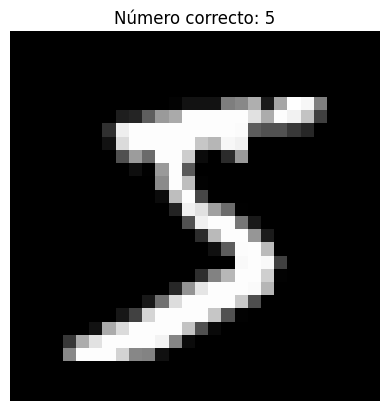

Mínimo: 0.0
Máximo: 1.0


In [2]:
import matplotlib.pyplot as plt

plt.imshow(x_train_mnist[0], cmap="gray")
plt.title(f"Número correcto: {y_train_mnist[0]}")
plt.axis("off")
plt.show()

x_train_mnist = x_train_mnist.astype("float32") / 255.0
x_test_mnist = x_test_mnist.astype("float32") / 255.0

print("Mínimo:", x_train_mnist.min())
print("Máximo:", x_train_mnist.max())


In [3]:
import tensorflow as tf

tf.random.set_seed(42)

modelo_mnist = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

modelo_mnist.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
modelo_mnist.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

historial_mnist = modelo_mnist.fit(
    x_train_mnist,
    y_train_mnist,
    epochs=5,
    validation_split=0.1
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9189 - loss: 0.2802 - val_accuracy: 0.9642 - val_loss: 0.1259
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9636 - loss: 0.1236 - val_accuracy: 0.9723 - val_loss: 0.0990
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9759 - loss: 0.0826 - val_accuracy: 0.9733 - val_loss: 0.0912
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9825 - loss: 0.0597 - val_accuracy: 0.9730 - val_loss: 0.0928
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9874 - loss: 0.0442 - val_accuracy: 0.9745 - val_loss: 0.0895


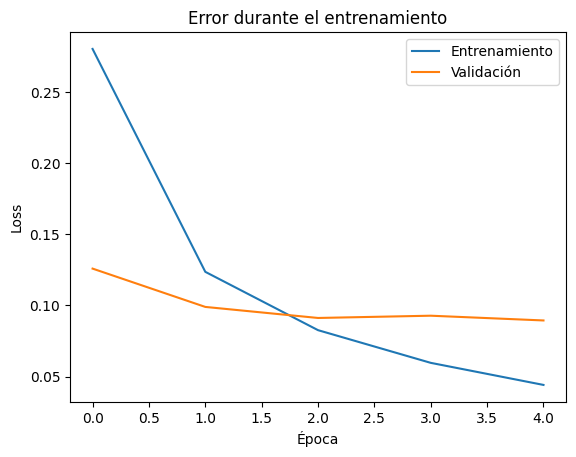

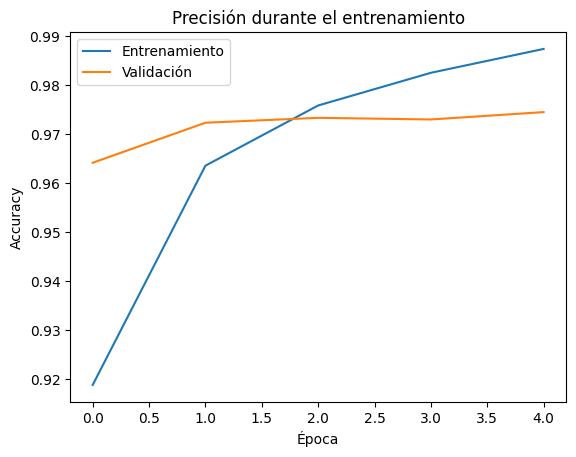

In [5]:
plt.plot(historial_mnist.history["loss"], label="Entrenamiento")
plt.plot(historial_mnist.history["val_loss"], label="Validación")
plt.title("Error durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(historial_mnist.history["accuracy"], label="Entrenamiento")
plt.plot(historial_mnist.history["val_accuracy"], label="Validación")
plt.title("Precisión durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [6]:
test_loss_mnist, test_accuracy_mnist = modelo_mnist.evaluate(
    x_test_mnist,
    y_test_mnist,
    verbose=0
)

print("Error de prueba:", test_loss_mnist)
print("Accuracy de prueba:", test_accuracy_mnist)

predicciones_mnist = modelo_mnist.predict(x_test_mnist[:10], verbose=0)

for i in range(10):
    prediccion = np.argmax(predicciones_mnist[i])
    print("Imagen", i + 1, "| Real:", y_test_mnist[i], "| Predicción:", prediccion)


Error de prueba: 0.0877922996878624
Accuracy de prueba: 0.9732999801635742
Imagen 1 | Real: 7 | Predicción: 7
Imagen 2 | Real: 2 | Predicción: 2
Imagen 3 | Real: 1 | Predicción: 1
Imagen 4 | Real: 0 | Predicción: 0
Imagen 5 | Real: 4 | Predicción: 4
Imagen 6 | Real: 1 | Predicción: 1
Imagen 7 | Real: 4 | Predicción: 4
Imagen 8 | Real: 9 | Predicción: 9
Imagen 9 | Real: 5 | Predicción: 6
Imagen 10 | Real: 9 | Predicción: 9


Cantidad de errores: 267


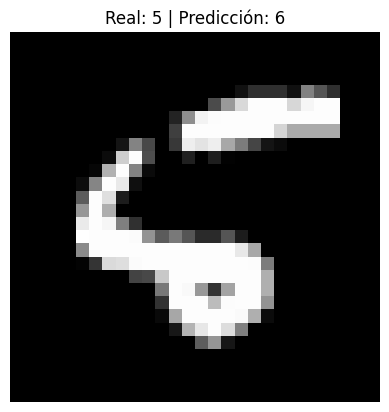

In [7]:
predicciones_todas = modelo_mnist.predict(x_test_mnist, verbose=0)
clases_predichas = np.argmax(predicciones_todas, axis=1)
errores = np.where(clases_predichas != y_test_mnist)[0]

print("Cantidad de errores:", len(errores))

indice_error = errores[0]
plt.imshow(x_test_mnist[indice_error], cmap="gray")
plt.title(
    f"Real: {y_test_mnist[indice_error]} | "
    f"Predicción: {clases_predichas[indice_error]}"
)
plt.axis("off")
plt.show()
